
# AES Hardware Trojan Detection — Extended Robustness & Complexity Notebook

This notebook reproduces and extends your pipeline with the following:
- **Dual-channel CNN** (GAF + raw reshape)
- Clean train/val split, consistent normalization
- Robustness hooks (noise sweep scaffolding left in place)
- **Section 4.5 probes** for **parameters**, **(optional) FLOPs**, **latency (CPU/GPU)**, **training wall-clock**, and **memory**

> Tip: Run top-to-bottom. If you want FLOPs numbers, install `ptflops` in your environment (`pip install ptflops`) before running the probes cell.


## 0) Imports & Setup

In [1]:

# Standard / scientific
import os, random, time, platform, csv
from pathlib import Path
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import cv2

# Torch
import torch
import torch.nn as nn
import torch.optim as optim
import torch.nn.functional as F
from torch.utils.data import DataLoader, TensorDataset

# Sklearn / pyts
from sklearn.model_selection import train_test_split
from sklearn.metrics import accuracy_score
from sklearn.svm import OneClassSVM
from pyts.image import MarkovTransitionField, GramianAngularField

# Reproducibility & device
def set_seed(seed=42):
    random.seed(seed); np.random.seed(seed)
    torch.manual_seed(seed); torch.cuda.manual_seed_all(seed)
set_seed(42)

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print("Using device:", device)


Using device: cuda


## 1) Parameters

In [2]:

# Data & experiment
num_epochs       = 20            # increase for real training
sample_numbers   = 10000         # per class (as in your script)
im_size          = 64
batch_size_trans = 100           # batching for transforms
n_bins           = 64
strategy_selection = 'uniform'   # 'uniform' or 'quantile'

data_names   = ["T500"]          # extend if needed
class_labels = {data_names[0]: 1}  # map dataset to positive label
num_classes  = 2

# File paths (adjust for your machine)
base_path = "D:/AIoT_project/data_sets/IEEE_dataPort/"

# Output
results_csv_path = f'validation_results_comparison_{data_names[0]}_extended.csv'


## 2) Utilities (resize, reshape, transforms)

In [3]:

def resize_dataset(dataset, new_size=(128, 128)):
    num_samples = dataset.shape[0]
    resized_dataset = np.zeros((num_samples, 1, new_size[0], new_size[1]), dtype=np.float32)
    for i in range(num_samples):
        image = dataset[i, 0, :, :]
        resized_image = cv2.resize(image, new_size, interpolation=cv2.INTER_AREA)
        resized_dataset[i, 0, :, :] = resized_image
    return resized_dataset

def derive_grid(signal_len):
    if signal_len == 2500:
        return 50, 50
    # near-square fallback
    h = int(np.floor(np.sqrt(signal_len)))
    w = int(np.ceil(signal_len / h))
    return h, w

def reshape_raw_to_image(X, h, w, out_size):
    # pad or trim to fill the grid
    if X.shape[1] != h*w:
        pad = h*w - X.shape[1]
        if pad > 0:
            Xp = np.pad(X, ((0,0),(0,pad)), mode='constant')
        else:
            Xp = X[:, :h*w]
    else:
        Xp = X
    X_img = Xp.reshape(-1, 1, h, w)
    return resize_dataset(X_img, new_size=(out_size, out_size))

def transform_data(X, im_size, n_bins, strategy_selection, batch_size,
                   transform_method='MTF', validation=False, stats=None, use_transformation=True,
                   raw_grid=None):
    # Transformation branch
    if use_transformation:
        if transform_method.upper() == 'MTF':
            Transformer = MarkovTransitionField(image_size=im_size, n_bins=n_bins, strategy=strategy_selection)
        elif transform_method.upper() == 'GAF':
            Transformer = GramianAngularField(image_size=im_size, method='summation')
        else:
            raise ValueError("transform_method must be 'MTF' or 'GAF'")
        # batched transform
        n_samples = X.shape[0]
        chunks = []
        for i in range(0, n_samples, batch_size):
            batch = X[i:i+batch_size]
            chunks.append(Transformer.transform(batch))
        X_trans = np.concatenate(chunks, axis=0)

        if validation and stats is not None and stats['mean_trans'] is not None:
            mean_trans, std_trans = stats['mean_trans'], stats['std_trans']
        else:
            mean_trans = X_trans.mean()
            std_trans  = X_trans.std() + 1e-8
        X_trans_norm = ((X_trans - mean_trans) / std_trans).astype(np.float32)
        X_trans_norm = X_trans_norm.reshape(-1, 1, im_size, im_size)
    else:
        X_trans_norm = None
        mean_trans = std_trans = None

    # Raw branch (image)
    if raw_grid is None:
        RAW_H, RAW_W = derive_grid(X.shape[1])
    else:
        RAW_H, RAW_W = raw_grid

    X_cnn_resized = reshape_raw_to_image(X, h=RAW_H, w=RAW_W, out_size=im_size)
    if validation and stats is not None and stats['mean_cnn'] is not None:
        mean_cnn, std_cnn = stats['mean_cnn'], stats['std_cnn']
    else:
        mean_cnn = X_cnn_resized.mean()
        std_cnn  = X_cnn_resized.std() + 1e-8
    X_cnn_norm = ((X_cnn_resized - mean_cnn) / std_cnn).astype(np.float32)

    normalization_stats = {
        'mean_trans': mean_trans,
        'std_trans' : std_trans,
        'mean_cnn'  : mean_cnn,
        'std_cnn'   : std_cnn
    }
    return X_trans_norm, X_cnn_norm, normalization_stats


## 3) Load Data (AES-T500)

In [4]:

train_data, val_data = [], []

for data_name in data_names:
    for trj_status in ["TrojanDisabled", "TrojanTriggered"]:
        data_folder = Path(f"{base_path}AES-{data_name}_power_Temp25C/"
                           f"AES-{data_name}_power_Temp25C/"
                           f"AES-{data_name}+{trj_status}_1/"
                           f"AES-{data_name}+{trj_status}_1")
        print("Loading from:", data_folder)
        labeled_arrays = []
        for i in range(sample_numbers):
            file_path = data_folder / f"Sample_{i}.csv"
            data = pd.read_csv(file_path, header=None)
            array = data[0].to_numpy()
            label = 0 if trj_status == "TrojanDisabled" else class_labels[data_name]
            labeled_array = np.append(array, label)
            labeled_arrays.append(labeled_array)
        tr_split, va_split = train_test_split(labeled_arrays, test_size=0.2, random_state=42, shuffle=True)
        train_data.extend(tr_split)
        val_data.extend(va_split)

train_data = np.array(train_data)
val_data   = np.array(val_data)
np.random.shuffle(train_data); np.random.shuffle(val_data)

X_train = train_data[:, :-1]
X_val   = val_data[:, :-1]
y_train = train_data[:, -1].astype(np.int64)
y_val   = val_data[:, -1].astype(np.int64)

SIGNAL_LEN = X_train.shape[1]
RAW_H, RAW_W = derive_grid(SIGNAL_LEN)
print(f"Signal length = {SIGNAL_LEN}, raw grid = {RAW_H}x{RAW_W}, resized to {im_size}x{im_size}")


Loading from: D:\AIoT_project\data_sets\IEEE_dataPort\AES-T500_power_Temp25C\AES-T500_power_Temp25C\AES-T500+TrojanDisabled_1\AES-T500+TrojanDisabled_1
Loading from: D:\AIoT_project\data_sets\IEEE_dataPort\AES-T500_power_Temp25C\AES-T500_power_Temp25C\AES-T500+TrojanTriggered_1\AES-T500+TrojanTriggered_1
Signal length = 2500, raw grid = 50x50, resized to 64x64


## 4) DataLoaders

In [5]:

def create_dataloaders_dual_channel(X_train_arr, X_val_arr, y_train, y_val):
    pin = (device.type == "cuda")
    train_dataset = TensorDataset(torch.tensor(X_train_arr, dtype=torch.float32),
                                  torch.tensor(y_train,     dtype=torch.long))
    val_dataset   = TensorDataset(torch.tensor(X_val_arr,   dtype=torch.float32),
                                  torch.tensor(y_val,       dtype=torch.long))
    train_loader = DataLoader(train_dataset, batch_size=32, shuffle=True,  pin_memory=pin, num_workers=2)
    val_loader   = DataLoader(val_dataset,   batch_size=32, shuffle=False, pin_memory=pin, num_workers=2)
    return train_loader, val_loader

class CustomDatasetDualPath(torch.utils.data.Dataset):
    def __init__(self, trans_images, cnn_images, labels):
        self.trans_images = trans_images
        self.cnn_images   = cnn_images
        self.labels       = labels
    def __len__(self): return len(self.labels)
    def __getitem__(self, idx):
        return self.trans_images[idx], self.cnn_images[idx], self.labels[idx]

def create_dataloaders_dual_path(X_train_trans, X_train_cnn, X_val_trans, X_val_cnn, y_train, y_val):
    pin = (device.type == "cuda")
    train_dataset = CustomDatasetDualPath(torch.tensor(X_train_trans, dtype=torch.float32),
                                          torch.tensor(X_train_cnn,   dtype=torch.float32),
                                          torch.tensor(y_train,       dtype=torch.long))
    val_dataset   = CustomDatasetDualPath(torch.tensor(X_val_trans,   dtype=torch.float32),
                                          torch.tensor(X_val_cnn,     dtype=torch.float32),
                                          torch.tensor(y_val,         dtype=torch.long))
    train_loader = DataLoader(train_dataset, batch_size=32, shuffle=True,  pin_memory=pin, num_workers=2)
    val_loader   = DataLoader(val_dataset,   batch_size=32, shuffle=False, pin_memory=pin, num_workers=2)
    return train_loader, val_loader


## 5) Models

In [6]:

class SEBlock(nn.Module):
    def __init__(self, in_channels, reduction_ratio=16):
        super().__init__()
        self.squeeze = nn.AdaptiveAvgPool2d(1)
        r = max(1, in_channels // reduction_ratio)
        self.excitation = nn.Sequential(
            nn.Linear(in_channels, r),
            nn.ReLU(inplace=True),
            nn.Linear(r, in_channels),
            nn.Sigmoid()
        )
    def forward(self, x):
        b, c, _, _ = x.size()
        s = self.squeeze(x).view(b, c)
        e = self.excitation(s).view(b, c, 1, 1)
        return x * e

class _Head(nn.Module):
    def __init__(self, in_ch=1):
        super().__init__()
        self.conv1 = nn.Conv2d(in_ch, 32, kernel_size=3, stride=1, padding=1)
        self.bn1   = nn.BatchNorm2d(32)
        self.se1   = SEBlock(32)
        self.conv2 = nn.Conv2d(32, 64, kernel_size=3, stride=1, padding=1)
        self.bn2   = nn.BatchNorm2d(64)
        self.se2   = SEBlock(64)
        self.pool  = nn.MaxPool2d(2, 2)  # 64->32->16 for 64x64 input
        self.dropout = nn.Dropout(0.5)
        self._proj  = None
    def forward(self, x):
        x = self.pool(self.se1(F.relu(self.bn1(self.conv1(x)))))
        x = self.pool(self.se2(F.relu(self.bn2(self.conv2(x)))))
        x = torch.flatten(x, 1)
        if self._proj is None:
            self._proj = nn.Sequential(nn.Linear(x.shape[1], 128)).to(x.device)
        x = F.relu(self._proj(x))
        return self.dropout(x)

class TransModule(nn.Module):
    def __init__(self): super().__init__(); self.body = _Head(1)
    def forward(self, x): return self.body(x)

class RawModule(nn.Module):
    def __init__(self): super().__init__(); self.body = _Head(1)
    def forward(self, x): return self.body(x)

class DualPathModel(nn.Module):
    def __init__(self, num_classes):
        super().__init__()
        self.trans_module = TransModule()
        self.raw_module   = RawModule()
        self.fc1 = nn.Linear(256, 128)
        self.fc2 = nn.Linear(128, num_classes)
    def forward(self, trans_input, raw_input):
        t = self.trans_module(trans_input)
        r = self.raw_module(raw_input)
        x = torch.cat([t, r], dim=1)
        return self.fc2(F.relu(self.fc1(x)))

def DualChannelModel(num_classes):
    # EXACTLY like your snippet
    return nn.Sequential(
        nn.Conv2d(2, 32, kernel_size=3, stride=1, padding=2),
        nn.ReLU(),
        nn.MaxPool2d(kernel_size=2, stride=2),
        nn.Conv2d(32, 64, kernel_size=3, stride=1, padding=2),
        nn.ReLU(),
        nn.MaxPool2d(kernel_size=2, stride=2),
        nn.Flatten(),
        nn.LazyLinear(100),
        nn.ReLU(),
        nn.Linear(100, num_classes)
    )

def RawOnlyModel(num_classes):
    return nn.Sequential(
        nn.Conv2d(1, 32, kernel_size=3, stride=1, padding=1), nn.ReLU(),
        nn.MaxPool2d(2,2),
        nn.Conv2d(32, 64, kernel_size=3, stride=1, padding=1), nn.ReLU(),
        nn.MaxPool2d(2,2),
        nn.AdaptiveAvgPool2d(1),
        nn.Flatten(),
        nn.Linear(64, 128), nn.ReLU(),
        nn.Linear(128, num_classes)
    )

TransOnlyModel = RawOnlyModel

class MLPModel(nn.Module):
    def __init__(self, input_size, num_classes):
        super().__init__()
        self.fc1 = nn.Linear(input_size, 32)
        self.fc2 = nn.Linear(32, 16)
        self.fc3 = nn.Linear(16, num_classes)
    def forward(self, x):
        x = x.view(x.size(0), -1)
        x = F.relu(self.fc1(x)); x = F.relu(self.fc2(x))
        return self.fc3(x)

class OneDCNNModel(nn.Module):
    def __init__(self, num_classes):
        super().__init__()
        self.conv1 = nn.Conv1d(1, 32, kernel_size=7, padding=3)
        self.conv2 = nn.Conv1d(32, 32, kernel_size=5, padding=2)
        self.pool  = nn.MaxPool1d(2)
        self.gap   = nn.AdaptiveAvgPool1d(1)
        self.fc1   = nn.Linear(32, 32)
        self.fc2   = nn.Linear(32, num_classes)
    def forward(self, x):  # (B,1,T)
        x = self.pool(F.relu(self.conv1(x)))
        x = self.pool(F.relu(self.conv2(x)))
        x = self.gap(x).squeeze(-1)
        return self.fc2(F.relu(self.fc1(x)))

class LSTMModel(nn.Module):
    def __init__(self, input_size=1, hidden_size=64, num_layers=2, num_classes=2, bidirectional=False):
        super().__init__()
        self.hidden_size   = hidden_size
        self.num_layers    = num_layers
        self.bidirectional = bidirectional
        self.lstm = nn.LSTM(input_size, hidden_size, num_layers,
                            batch_first=True, bidirectional=bidirectional)
        out_dim = hidden_size * (2 if bidirectional else 1)
        self.fc = nn.Linear(out_dim, num_classes)
    def forward(self, x):  # x: (B,1,T)
        x = x.transpose(1, 2)  # -> (B,T,1)
        B = x.size(0); D = 2 if self.bidirectional else 1
        h0 = torch.zeros(self.num_layers*D, B, self.hidden_size, device=x.device)
        c0 = torch.zeros(self.num_layers*D, B, self.hidden_size, device=x.device)
        out, _ = self.lstm(x, (h0, c0))   # (B,T,H*D)
        out = out[:, -1, :]
        return self.fc(out)


## 6) Train / Eval & Robustness

In [7]:
def train_and_evaluate(model, train_loader, val_loader, num_epochs, criterion, optimizer):
    model.to(device)
    train_losses, val_losses, val_accuracies = [], [], []
    t0 = time.perf_counter()
    for epoch in range(num_epochs):
        model.train()
        running_train_loss = 0.0
        for batch in train_loader:
            optimizer.zero_grad()
            if len(batch) == 2:
                inputs, labels = batch
                inputs, labels = inputs.to(device), labels.to(device)
                outputs = model(inputs)
            else:
                trans_images, raw_images, labels = batch
                trans_images, raw_images = trans_images.to(device), raw_images.to(device)
                labels = labels.to(device)
                outputs = model(trans_images, raw_images)
            loss = criterion(outputs, labels)
            loss.backward()
            optimizer.step()
            running_train_loss += loss.item()

        # Validation
        model.eval()
        running_val_loss, all_labels, all_preds = 0.0, [], []
        with torch.no_grad():
            for batch in val_loader:
                if len(batch) == 2:
                    inputs, labels = batch
                    inputs, labels = inputs.to(device), labels.to(device)
                    outputs = model(inputs)
                else:
                    trans_images, raw_images, labels = batch
                    trans_images, raw_images = trans_images.to(device), raw_images.to(device)
                    labels = labels.to(device)
                    outputs = model(trans_images, raw_images)
                loss = criterion(outputs, labels)
                running_val_loss += loss.item()
                _, predicted = outputs.max(1)
                all_labels.extend(labels.cpu().numpy())
                all_preds.extend(predicted.cpu().numpy())

        avg_train_loss = running_train_loss / max(1, len(train_loader))
        avg_val_loss   = running_val_loss   / max(1, len(val_loader))
        acc = accuracy_score(all_labels, all_preds) * 100
        print(f"Epoch [{epoch+1}/{num_epochs}] "
              f"Train {avg_train_loss:.4f} | Val {avg_val_loss:.4f} | Acc {acc:.2f}%")
        train_losses.append(avg_train_loss)
        val_losses.append(avg_val_loss)
        val_accuracies.append(acc)
    t1 = time.perf_counter()
    print(f"Total training wall-clock: {(t1 - t0)/60.0:.1f} min | "
          f"{(t1-t0)/num_epochs:.2f} s/epoch")
    return train_losses, val_losses, val_accuracies


def evaluate_robustness(model, transform_method, combination_method, train_stats,
                        noise_levels, criterion, use_transformation=True):
    robust_val_losses, robust_val_accuracies, results = [], [], []
    model.eval()
    for noise_std_dev in noise_levels:
        X_val_noise = X_val + np.random.normal(0, noise_std_dev, X_val.shape)

        if combination_method in ['cnn1d', 'lstm']:
            X_val_seq = torch.tensor(X_val_noise[:, None, :], dtype=torch.float32)
            y_val_tensor = torch.tensor(y_val, dtype=torch.long)
            val_loader_noise = DataLoader(TensorDataset(X_val_seq, y_val_tensor), batch_size=32)

            def model_forward(batch):
                inputs, labels = batch
                return model(inputs.to(device)), labels.to(device)

        elif combination_method in ['raw_only', 'mlp']:
            _, noisy_raw, _ = transform_data(
                X_val_noise, im_size, n_bins, strategy_selection, batch_size_trans,
                transform_method='MTF', validation=True, stats=train_stats,
                use_transformation=False, raw_grid=(RAW_H, RAW_W)
            )
            val_loader_noise = DataLoader(
                TensorDataset(torch.tensor(noisy_raw, dtype=torch.float32),
                              torch.tensor(y_val, dtype=torch.long)),
                batch_size=32
            )
            def model_forward(batch):
                inputs, labels = batch
                return model(inputs.to(device)), labels.to(device)

        elif combination_method == 'trans_only':
            noisy_trans, _, _ = transform_data(
                X_val_noise, im_size, n_bins, strategy_selection, batch_size_trans,
                transform_method=transform_method, validation=True, stats=train_stats,
                use_transformation=True, raw_grid=(RAW_H, RAW_W)
            )
            val_loader_noise = DataLoader(
                TensorDataset(torch.tensor(noisy_trans, dtype=torch.float32),
                              torch.tensor(y_val, dtype=torch.long)),
                batch_size=32
            )
            def model_forward(batch):
                inputs, labels = batch
                return model(inputs.to(device)), labels.to(device)

        elif combination_method == 'dual_channel':
            noisy_trans, noisy_raw, _ = transform_data(
                X_val_noise, im_size, n_bins, strategy_selection, batch_size_trans,
                transform_method=transform_method, validation=True, stats=train_stats,
                use_transformation=True, raw_grid=(RAW_H, RAW_W)
            )
            X_val_comb = np.concatenate((noisy_raw, noisy_trans), axis=1)
            val_loader_noise = DataLoader(
                TensorDataset(torch.tensor(X_val_comb, dtype=torch.float32),
                              torch.tensor(y_val, dtype=torch.long)),
                batch_size=32
            )
            def model_forward(batch):
                inputs, labels = batch
                return model(inputs.to(device)), labels.to(device)

        elif combination_method == 'dual_path':
            noisy_trans, noisy_raw, _ = transform_data(
                X_val_noise, im_size, n_bins, strategy_selection, batch_size_trans,
                transform_method=transform_method, validation=True, stats=train_stats,
                use_transformation=True, raw_grid=(RAW_H, RAW_W)
            )
            val_dataset_noise = CustomDatasetDualPath(
                torch.tensor(noisy_trans, dtype=torch.float32),
                torch.tensor(noisy_raw, dtype=torch.float32),
                torch.tensor(y_val, dtype=torch.long)
            )
            val_loader_noise = DataLoader(val_dataset_noise, batch_size=32)

            def model_forward(batch):
                trans_images, raw_images, labels = batch
                outs = model(trans_images.to(device), raw_images.to(device))
                return outs, labels.to(device)
        else:
            raise ValueError(f"Unknown combination_method: {combination_method}")

        # Evaluate
        running_loss, correct, total = 0.0, 0, 0
        with torch.no_grad():
            for batch in val_loader_noise:
                outputs, labels = model_forward(batch)
                loss = criterion(outputs, labels)
                running_loss += loss.item()
                _, predicted = outputs.max(1)
                total   += labels.size(0)
                correct += (predicted == labels).sum().item()

        avg_loss = running_loss / max(1, len(val_loader_noise))
        acc = 100.0 * correct / max(1, total)
        robust_val_losses.append(avg_loss)
        robust_val_accuracies.append(acc)
        results.append({
            'noise_std_dev': float(noise_std_dev),
            'val_loss': float(avg_loss),
            'val_accuracy': float(acc)
        })
        print(f"Noise Std Dev: {noise_std_dev:.2f}, Accuracy: {acc:.2f}%")

    return robust_val_losses, robust_val_accuracies, results


## 7) Variants & Main Loop

In [ ]:

# Choose from: 'dual_channel', 'dual_path', 'raw_only', 'trans_only', 'mlp', 'cnn1d', 'lstm', 'ocsvm'
variants = [
    {'transform_method': 'GAF', 'combination_method': 'dual_channel'},
]

all_results = {}

for var in variants:
    tm = var['transform_method']
    cm = var['combination_method']
    print(f"\n--- Running Variant: {tm} + {cm} ---")

    train_loader = val_loader = None
    model_inst = None
    use_trans = False
    train_stats = None

    if cm == 'raw_only':
        _, X_train_raw, train_stats = transform_data(
            X_train, im_size, n_bins, strategy_selection, batch_size_trans,
            transform_method='MTF', validation=False, stats=None, use_transformation=False, raw_grid=(RAW_H, RAW_W)
        )
        _, X_val_raw, _ = transform_data(
            X_val, im_size, n_bins, strategy_selection, batch_size_trans,
            transform_method='MTF', validation=True, stats=train_stats, use_transformation=False, raw_grid=(RAW_H, RAW_W)
        )
        X_train_tensor = torch.tensor(X_train_raw, dtype=torch.float32)
        X_val_tensor   = torch.tensor(X_val_raw, dtype=torch.float32)
        train_loader   = DataLoader(TensorDataset(X_train_tensor, torch.tensor(y_train, dtype=torch.long)), batch_size=32, shuffle=True)
        val_loader     = DataLoader(TensorDataset(X_val_tensor,   torch.tensor(y_val,   dtype=torch.long)), batch_size=32)
        model_inst = RawOnlyModel(num_classes)

    elif cm == 'trans_only':
        X_train_trans, _, train_stats = transform_data(
            X_train, im_size, n_bins, strategy_selection, batch_size_trans,
            transform_method=tm, validation=False, stats=None, use_transformation=True, raw_grid=(RAW_H, RAW_W)
        )
        X_val_trans, _, _ = transform_data(
            X_val, im_size, n_bins, strategy_selection, batch_size_trans,
            transform_method=tm, validation=True, stats=train_stats, use_transformation=True, raw_grid=(RAW_H, RAW_W)
        )
        X_train_tensor = torch.tensor(X_train_trans, dtype=torch.float32)
        X_val_tensor   = torch.tensor(X_val_trans,  dtype=torch.float32)
        train_loader   = DataLoader(TensorDataset(X_train_tensor, torch.tensor(y_train, dtype=torch.long)), batch_size=32, shuffle=True)
        val_loader     = DataLoader(TensorDataset(X_val_tensor,   torch.tensor(y_val,   dtype=torch.long)), batch_size=32)
        model_inst = TransOnlyModel(num_classes)
        use_trans = True

    elif cm == 'dual_channel':
        X_train_trans, X_train_raw, train_stats = transform_data(
            X_train, im_size, n_bins, strategy_selection, batch_size_trans,
            transform_method=tm, validation=False, stats=None, use_transformation=True, raw_grid=(RAW_H, RAW_W)
        )
        X_val_trans, X_val_raw, _ = transform_data(
            X_val, im_size, n_bins, strategy_selection, batch_size_trans,
            transform_method=tm, validation=True, stats=train_stats, use_transformation=True, raw_grid=(RAW_H, RAW_W)
        )
        X_train_comb = np.concatenate((X_train_raw, X_train_trans), axis=1)
        X_val_comb   = np.concatenate((X_val_raw,  X_val_trans ), axis=1)
        train_loader, val_loader = create_dataloaders_dual_channel(X_train_comb, X_val_comb, y_train, y_val)
        model_inst = DualChannelModel(num_classes)
        use_trans = True

    elif cm == 'dual_path':
        X_train_trans, X_train_raw, train_stats = transform_data(
            X_train, im_size, n_bins, strategy_selection, batch_size_trans,
            transform_method=tm, validation=False, stats=None, use_transformation=True, raw_grid=(RAW_H, RAW_W)
        )
        X_val_trans, X_val_raw, _ = transform_data(
            X_val, im_size, n_bins, strategy_selection, batch_size_trans,
            transform_method=tm, validation=True, stats=train_stats, use_transformation=True, raw_grid=(RAW_H, RAW_W)
        )
        train_loader, val_loader = create_dataloaders_dual_path(X_train_trans, X_train_raw, X_val_trans, X_val_raw, y_train, y_val)
        model_inst = DualPathModel(num_classes)
        use_trans = True

    elif cm == 'mlp':
        _, X_train_raw, train_stats = transform_data(
            X_train, im_size, n_bins, strategy_selection, batch_size_trans,
            transform_method='MTF', validation=False, use_transformation=False, raw_grid=(RAW_H, RAW_W)
        )
        _, X_val_raw, _ = transform_data(
            X_val, im_size, n_bins, strategy_selection, batch_size_trans,
            transform_method='MTF', validation=True, stats=train_stats, use_transformation=False, raw_grid=(RAW_H, RAW_W)
        )
        input_size = X_train_raw.shape[2] * X_train_raw.shape[3]
        X_train_tensor = torch.tensor(X_train_raw, dtype=torch.float32)
        X_val_tensor   = torch.tensor(X_val_raw,   dtype=torch.float32)
        train_loader   = DataLoader(TensorDataset(X_train_tensor, torch.tensor(y_train, dtype=torch.long)), batch_size=32, shuffle=True)
        val_loader     = DataLoader(TensorDataset(X_val_tensor,   torch.tensor(y_val,   dtype=torch.long)), batch_size=32)
        model_inst = MLPModel(input_size, num_classes)

    elif cm == 'cnn1d':
        X_train_seq = torch.tensor(X_train[:, None, :], dtype=torch.float32)
        X_val_seq   = torch.tensor(X_val[:,   None, :], dtype=torch.float32)
        train_loader  = DataLoader(TensorDataset(X_train_seq, torch.tensor(y_train, dtype=torch.long)), batch_size=32, shuffle=True)
        val_loader    = DataLoader(TensorDataset(X_val_seq,   torch.tensor(y_val,   dtype=torch.long)), batch_size=32)
        model_inst = OneDCNNModel(num_classes)

    elif cm == 'lstm':
        X_train_seq = torch.tensor(X_train[:, None, :], dtype=torch.float32)
        X_val_seq   = torch.tensor(X_val[:,   None, :], dtype=torch.float32)
        train_loader  = DataLoader(TensorDataset(X_train_seq, torch.tensor(y_train, dtype=torch.long)), batch_size=32, shuffle=True)
        val_loader    = DataLoader(TensorDataset(X_val_seq,   torch.tensor(y_val,   dtype=torch.long)), batch_size=32)
        model_inst = LSTMModel(input_size=1, hidden_size=64, num_layers=2, num_classes=num_classes)

    elif cm == 'ocsvm':
        _, X_train_raw, train_stats = transform_data(
            X_train, im_size, n_bins, strategy_selection, batch_size_trans,
            transform_method='MTF', validation=False, use_transformation=False, raw_grid=(RAW_H, RAW_W)
        )
        X_train_flat = X_train_raw.reshape(X_train_raw.shape[0], -1)
        oc_svm = OneClassSVM(kernel='rbf', gamma='scale', nu=0.1)
        print("Training OC-SVM on normal (label 0) only ...")
        oc_svm.fit(X_train_flat[y_train == 0])

        noise_levels = np.arange(0, 10.5, 0.5)
        res = []
        for noise_std_dev in noise_levels:
            noisy = X_val + np.random.normal(0, noise_std_dev, X_val.shape)
            _, X_val_raw_noisy, _ = transform_data(
                noisy, im_size, n_bins, strategy_selection, batch_size_trans,
                transform_method='MTF', validation=True, stats=train_stats, use_transformation=False, raw_grid=(RAW_H, RAW_W)
            )
            X_val_flat = X_val_raw_noisy.reshape(X_val_raw_noisy.shape[0], -1)
            preds = oc_svm.predict(X_val_flat)              # +1 inlier (normal), -1 outlier (trojan)
            preds_bin = np.where(preds == 1, 0, 1).astype(np.int64)
            acc = accuracy_score(y_val, preds_bin) * 100.0
            res.append({'noise_std_dev': float(noise_std_dev), 'val_accuracy': float(acc)})
            print(f"Noise {noise_std_dev:.2f}: Acc {acc:.2f}%")
        all_results["OCSVM_raw"] = {'robustness': res}
        continue

    else:
        raise ValueError(f"Unknown combination_method: {cm}")

    # Train NN models (with wall-clock printed inside function)
    criterion_inst = nn.CrossEntropyLoss()
    optimizer_inst = optim.Adam(model_inst.parameters(), lr=1e-4, weight_decay=1e-4)
    print("Training ...")
    train_losses, val_losses_clean, val_acc_clean = train_and_evaluate(
        model_inst, train_loader, val_loader, num_epochs, criterion_inst, optimizer_inst
    )

    # Robustness evaluation (disabled by default; set a sweep if needed)
    # Robustness evaluation (disabled by default; error-free)
    noise_levels = np.array([], dtype=float)   # <-- instead of np.arange(0, 0, 0)
    # print("Evaluating robustness ...")
    # robust_losses, robust_accuracies, res = evaluate_robustness(
    #     model_inst, tm, cm, train_stats, noise_levels, criterion_inst,
    #     use_transformation=(cm!='mlp' and cm!='cnn1d' and cm!='lstm')
    # )


    # all_results[f"{tm}_{cm}"] = {
    #     'clean_val_acc': val_acc_clean,
    #     'clean_val_loss': val_losses_clean,
    #     'robustness': res
    # }



--- Running Variant: GAF + dual_channel ---
Training ...
Epoch [1/20] Train 0.0997 | Val 0.0903 | Acc 97.97%
Epoch [2/20] Train 0.0835 | Val 0.0884 | Acc 97.97%
Epoch [3/20] Train 0.0806 | Val 0.0977 | Acc 97.97%
Epoch [4/20] Train 0.0796 | Val 0.0887 | Acc 97.97%
Epoch [5/20] Train 0.0770 | Val 0.0976 | Acc 97.97%
Epoch [6/20] Train 0.0764 | Val 0.0853 | Acc 97.97%
Epoch [7/20] Train 0.0751 | Val 0.0866 | Acc 97.97%
Epoch [8/20] Train 0.0747 | Val 0.0845 | Acc 97.97%
Epoch [9/20] Train 0.0718 | Val 0.0847 | Acc 97.97%
Epoch [10/20] Train 0.0717 | Val 0.0831 | Acc 97.97%
Epoch [11/20] Train 0.0701 | Val 0.0863 | Acc 97.97%
Epoch [12/20] Train 0.0673 | Val 0.0814 | Acc 97.97%
Epoch [13/20] Train 0.0651 | Val 0.0807 | Acc 97.97%
Epoch [14/20] Train 0.0637 | Val 0.0771 | Acc 97.97%
Epoch [15/20] Train 0.0621 | Val 0.0702 | Acc 97.97%
Epoch [16/20] Train 0.0587 | Val 0.0820 | Acc 98.02%
Epoch [17/20] Train 0.0567 | Val 0.0661 | Acc 97.97%
Epoch [18/20] Train 0.0539 | Val 0.0645 | Acc 98.0

NameError: name 'res' is not defined

## 8) Plot & Save Results

C:\Users\PC_ENG\AppData\Local\Temp\ipykernel_28956\1046420918.py:11: UserWarning: No artists with labels found to put in legend.  Note that artists whose label start with an underscore are ignored when legend() is called with no argument.
  plt.legend()


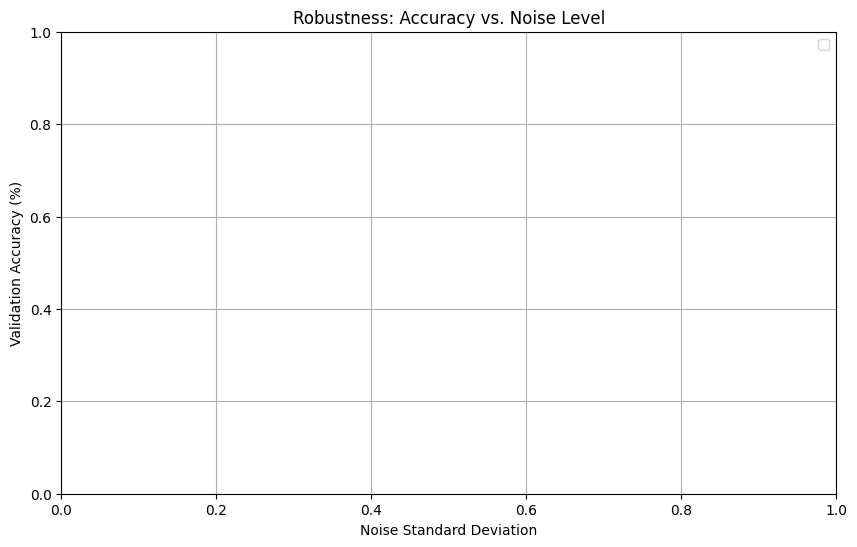

No robustness sweep configured; skip CSV.


In [9]:

plt.figure(figsize=(10, 6))
for key, result in all_results.items():
    if not result['robustness']:
        continue
    noise_lvls = [r['noise_std_dev'] for r in result['robustness']]
    accs       = [r['val_accuracy']   for r in result['robustness']]
    plt.plot(noise_lvls, accs, marker='o', label=key)
plt.xlabel("Noise Standard Deviation")
plt.ylabel("Validation Accuracy (%)")
plt.title("Robustness: Accuracy vs. Noise Level")
plt.legend()
plt.grid(True)
plt.show()

# Save flattened CSV
all_results_flat = []
for key, result in all_results.items():
    for r in result['robustness']:
        rr = dict(r)
        rr['variant'] = key
        all_results_flat.append(rr)
if all_results_flat:
    results_df = pd.DataFrame(all_results_flat)
    results_df.to_csv(results_csv_path, index=False)
    print(f"Results saved to {results_csv_path}")
else:
    print("No robustness sweep configured; skip CSV.")


## 9) Section 4.5 Probes — Params, FLOPs (optional), Latency (CPU/GPU), Memory, CSV Export

In [10]:
from contextlib import suppress

def count_params(model):
    return sum(p.numel() for p in model.parameters() if p.requires_grad)

def describe_model_complexity(model, input_shape, device):
    model = model.to(device).eval()
    dummy = torch.randn(*input_shape, device=device)

    # 🔧 Initialize Lazy modules by doing a dummy forward once
    with torch.no_grad():
        _ = model(dummy)
        if device.type == 'cuda':
            torch.cuda.synchronize()

    # Now it's safe to count parameters
    params = count_params(model)

    # FLOPs (optional; will be None if ptflops not installed or fails)
    flops = None
    with suppress(Exception):
        from ptflops import get_model_complexity_info
        # ptflops does not run the model; it traces shapes from `input_res`
        macs, _ = get_model_complexity_info(model, input_res=input_shape[1:],
                                            as_strings=False, print_per_layer_stat=False)
        flops = macs * 2  # MACs→FLOPs (approx)
    return params, flops

def measure_latency(model, input_shape=(1,2,64,64), device=torch.device('cpu'),
                    warmup=50, iters=200):
    model = model.to(device).eval()
    x = torch.randn(*input_shape, device=device)

    # Ensure Lazy layers are initialized before timing
    with torch.no_grad():
        _ = model(x)
        if device.type == 'cuda':
            torch.cuda.synchronize()

    # Warmup
    with torch.no_grad():
        for _ in range(warmup):
            _ = model(x)
            if device.type == 'cuda':
                torch.cuda.synchronize()

    # Timed loop
    t0 = time.perf_counter()
    with torch.no_grad():
        for _ in range(iters):
            _ = model(x)
            if device.type == 'cuda':
                torch.cuda.synchronize()
    t1 = time.perf_counter()
    return (t1 - t0) * 1000.0 / iters  # ms/sample

def report_memory():
    if torch.cuda.is_available():
        free, total = torch.cuda.mem_get_info()
        print(f"GPU VRAM total: {total/1e9:.2f} GB, free now: {free/1e9:.2f} GB")
    else:
        print("GPU not available; CPU RAM reporting is environment-specific.")

# --- Probe a representative model & input shape (DualChannel, 2x64x64)
probe_model = DualChannelModel(num_classes=2)
params, flops = describe_model_complexity(probe_model, (1,2,im_size,im_size), device)

cpu_ms = measure_latency(DualChannelModel(num_classes=2), (1,2,im_size,im_size), device=torch.device('cpu'))
gpu_ms = measure_latency(DualChannelModel(num_classes=2), (1,2,im_size,im_size), device=torch.device('cuda')) if torch.cuda.is_available() else None

print(f"Trainable parameters: {params/1e6:.3f} M")
print("FLOPs:", f"{flops/1e6:.1f} MFLOPs" if flops is not None else "n/a (install ptflops)")
print(f"Inference latency — CPU: {cpu_ms:.2f} ms" + (f", GPU: {gpu_ms:.2f} ms" if gpu_ms else ""))
report_memory()


# Save probe summary
summary = {
    "device": "GPU" if torch.cuda.is_available() else "CPU",
    "gpu_name": (torch.cuda.get_device_name(0) if torch.cuda.is_available() else "N/A"),
    "torch": torch.__version__,
    "python": platform.python_version(),
    "cpu_ms": round(cpu_ms, 3),
    "gpu_ms": round(gpu_ms, 3) if gpu_ms else None,
    "params_M": round(params/1e6, 3),
    "flops_M": round(flops/1e6, 1) if flops else None,
}
with open("complexity_runtime_probe.csv", "w", newline="") as f:
    writer = csv.DictWriter(f, fieldnames=summary.keys())
    writer.writeheader(); writer.writerow(summary)
print("Saved complexity_runtime_probe.csv")


c:\Users\PC_ENG\anaconda3\envs\AIoT_Project\Lib\site-packages\tqdm\auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


Trainable parameters: 1.869 M
FLOPs: 56.1 MFLOPs
Inference latency — CPU: 1.10 ms, GPU: 2.04 ms
GPU VRAM total: 25.77 GB, free now: 24.25 GB
Saved complexity_runtime_probe.csv


## 10) (Optional) Quick Single-Variant Run Helper

In [11]:

# Example: flip variants here if you want to re-run a different model quickly.
# variants = [{'transform_method': 'GAF', 'combination_method': 'dual_path'}]
# Re-run cell 7 after editing.
pass
